#HW1

Стаховой Екатерины, ПАДИИ, 3 курс

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
import torchvision.models as models

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
import time
import copy
from pathlib import Path

In [2]:
def set_seed(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    torch.backends.cudnn.deterministic = True

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Используемое устройство: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Используемое устройство: cuda
GPU: Tesla T4
VRAM: 15.6 GB


In [3]:
class NCSSDBlock(nn.Module):
    def __init__(self, dim, expand_ratio=2, dropout=0.1):
        super().__init__()
        self.dim = dim
        self.expand_dim = int(dim * expand_ratio)

        self.norm = nn.LayerNorm(dim)
        self.ssm_proj = nn.Linear(dim, self.expand_dim * 2, bias=False)
        self.conv = nn.Conv2d(self.expand_dim, self.expand_dim, kernel_size=3, padding=1, groups=self.expand_dim)
        self.non_causal_proj = nn.Sequential(
            nn.Linear(self.expand_dim, self.expand_dim),
            nn.GELU(),
            nn.Linear(self.expand_dim, dim)
        )
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        residual = x
        x = self.norm(x)

        B, H, W, C = x.shape

        x_ssm = self.ssm_proj(x)
        x_ssm, _ = x_ssm.chunk(2, dim=-1)

        x_conv = x_ssm.permute(0, 3, 1, 2)
        x_conv = self.conv(x_conv)
        x_conv = x_conv.permute(0, 2, 3, 1)

        x_out = self.non_causal_proj(x_conv)
        x_out = self.dropout(x_out)

        return x_out + residual

In [4]:
class VSSDStage(nn.Module):
    def __init__(self, dim, num_blocks, expand_ratio=2):
        super().__init__()
        self.blocks = nn.ModuleList([
            NCSSDBlock(dim, expand_ratio) for _ in range(num_blocks)
        ])

    def forward(self, x):
        for block in self.blocks:
            x = block(x)
        return x

In [5]:
class PatchEmbedding(nn.Module):
    def __init__(self, img_size=32, patch_size=2, in_chans=3, embed_dim=96):
        super().__init__()
        self.img_size = img_size
        self.patch_size = patch_size
        self.num_patches = (img_size // patch_size) ** 2

        self.proj = nn.Conv2d(in_chans, embed_dim, kernel_size=patch_size, stride=patch_size)
        self.norm = nn.LayerNorm(embed_dim)

    def forward(self, x):
        B, C, H, W = x.shape
        x = self.proj(x)
        x = x.flatten(2).transpose(1, 2)
        x = self.norm(x)

        Hp, Wp = H // self.patch_size, W // self.patch_size
        x = x.view(B, Hp, Wp, -1)
        return x


class VSSD(nn.Module):
    def __init__(self, img_size=32, patch_size=2, in_chans=3, num_classes=10,
                 embed_dim=96, depths=[2, 4, 2], expand_ratio=2, dropout=0.1):
        super().__init__()

        self.patch_embed = PatchEmbedding(img_size, patch_size, in_chans, embed_dim)
        num_patches = self.patch_embed.num_patches
        self.pos_embed = nn.Parameter(torch.randn(1, img_size//patch_size, img_size//patch_size, embed_dim) * 0.02)

        self.stages = nn.ModuleList()
        current_dim = embed_dim

        for i, depth in enumerate(depths):
            self.stages.append(VSSDStage(current_dim, depth, expand_ratio))
            if i < len(depths) - 1:
                next_dim = current_dim * 2
                self.stages.append(nn.Sequential(
                    nn.LayerNorm(current_dim),
                    nn.Linear(current_dim, next_dim),
                ))
                current_dim = next_dim

        self.final_dim = current_dim
        self.norm = nn.LayerNorm(self.final_dim)
        self.head = nn.Linear(self.final_dim, num_classes)

        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        B = x.shape[0]

        x = self.patch_embed(x)
        x = x + self.pos_embed
        for module in self.stages:
            if isinstance(module, VSSDStage):
                x = module(x)
            else:
                x = module(x)

        x = x.mean(dim=(1, 2))
        x = self.norm(x)
        x = self.dropout(x)
        x = self.head(x)

        return x

In [6]:
def create_vssd(num_classes=10):
    return VSSD(
        img_size=32,
        patch_size=2,
        embed_dim=64,
        depths=[2, 4, 2],
        expand_ratio=2,
        num_classes=num_classes
    )

In [7]:
train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])
train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=train_transform)
test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=test_transform)

batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)

print(f"Размер обучающей выборки: {len(train_dataset)}")
print(f"Размер тестовой выборки: {len(test_dataset)}")


Размер обучающей выборки: 50000
Размер тестовой выборки: 10000


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


In [8]:
class EarlyStopping:
    def __init__(self, patience=10, min_delta=0.001):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_score = None
        self.early_stop = False

    def __call__(self, val_loss):
        if self.best_score is None:
            self.best_score = val_loss
        elif val_loss > self.best_score - self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = val_loss
            self.counter = 0


def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    pbar = tqdm(loader, desc='Training', leave=False)
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        pbar.set_postfix({'loss': total_loss/(total/loader.batch_size),
                         'acc': 100.*correct/total})

    return total_loss / len(loader), 100. * correct / total


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        pbar = tqdm(loader, desc='Evaluating', leave=False)
        for images, labels in pbar:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return total_loss / len(loader), 100. * correct / total, all_preds, all_labels


In [9]:
def train_model(model, model_name, train_loader, test_loader, epochs=50, lr=0.001, device=device):

    model = model.to(device)

    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=5e-4)
    criterion = nn.CrossEntropyLoss()
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    early_stopping = EarlyStopping(patience=10)

    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss': [], 'val_acc': []
    }

    best_val_acc = 0
    best_model_state = None
    start_time = time.time()

    for epoch in range(epochs):
        epoch_start = time.time()

        train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion, device)
        val_loss, val_acc, _, _ = evaluate(model, test_loader, criterion, device)

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_state = copy.deepcopy(model.state_dict())

        scheduler.step()

        epoch_time = time.time() - epoch_start
        print(f"Epoch [{epoch+1}/{epochs}] | "
              f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
              f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}% | "
              f"Time: {epoch_time:.2f}s")

        early_stopping(val_loss)
        if early_stopping.early_stop:
            print(f"Early stopping triggered at epoch {epoch+1}")
            break

    print(f"Лучшая точность на валидации: {best_val_acc:.2f}%")

    model.load_state_dict(best_model_state)

    return model, history, best_val_acc

In [10]:
vssd_model = create_vssd(num_classes=10)
resnet_model = models.resnet50(num_classes=10)

resnet_model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
resnet_model.maxpool = nn.Identity()

In [11]:
vssd_model, vssd_history, vssd_best_acc = train_model(
    vssd_model, "VSSD", train_loader, test_loader,
    epochs=15, lr=0.001, device=device
)

Training:   0%|          | 0/391 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Evaluating:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch [1/15] | Train Loss: 1.8067 | Train Acc: 31.87% | Val Loss: 1.4936 | Val Acc: 44.83% | Time: 99.27s


Training:   0%|          | 0/391 [00:00<?, ?it/s]

...

Evaluating:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch [14/15] | Train Loss: 0.3396 | Train Acc: 88.37% | Val Loss: 0.3730 | Val Acc: 87.20% | Time: 94.87s


Training:   0%|          | 0/391 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch [15/15] | Train Loss: 0.3253 | Train Acc: 88.78% | Val Loss: 0.3713 | Val Acc: 87.30% | Time: 94.72s
Лучшая точность на валидации: 87.30%


In [12]:
resnet_model, resnet_history, resnet_best_acc = train_model(
    resnet_model, "ResNet50", train_loader, test_loader,
    epochs=15, lr=0.001, device=device
)

Training:   0%|          | 0/391 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch [1/15] | Train Loss: 1.6192 | Train Acc: 41.58% | Val Loss: 1.4422 | Val Acc: 51.50% | Time: 179.58s


Training:   0%|          | 0/391 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/79 [00:00<?, ?it/s]

...

Evaluating:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch [14/15] | Train Loss: 0.2089 | Train Acc: 92.69% | Val Loss: 0.2948 | Val Acc: 90.68% | Time: 178.64s


Training:   0%|          | 0/391 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch [15/15] | Train Loss: 0.1923 | Train Acc: 93.31% | Val Loss: 0.2980 | Val Acc: 90.73% | Time: 178.83s
Лучшая точность на валидации: 90.73%


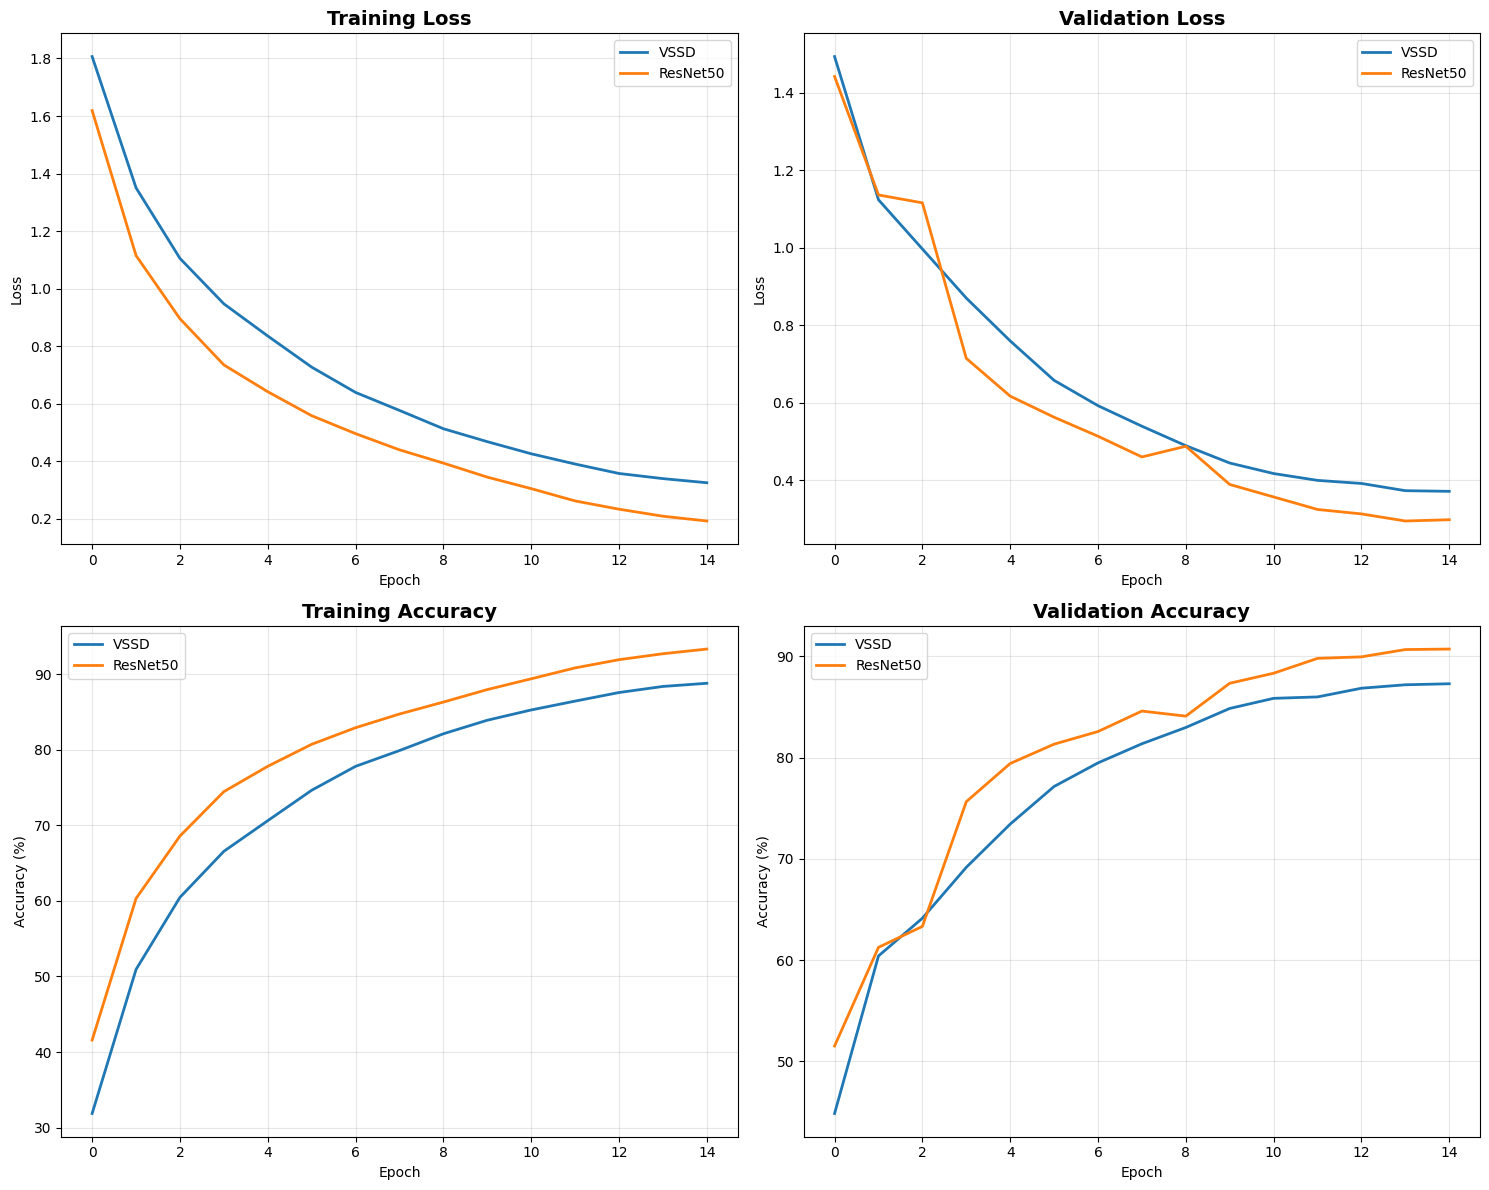

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

axes[0, 0].plot(vssd_history['train_loss'], label='VSSD', linewidth=2)
axes[0, 0].plot(resnet_history['train_loss'], label='ResNet50', linewidth=2)
axes[0, 0].set_title('Training Loss', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(vssd_history['val_loss'], label='VSSD', linewidth=2)
axes[0, 1].plot(resnet_history['val_loss'], label='ResNet50', linewidth=2)
axes[0, 1].set_title('Validation Loss', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(vssd_history['train_acc'], label='VSSD', linewidth=2)
axes[1, 0].plot(resnet_history['train_acc'], label='ResNet50', linewidth=2)
axes[1, 0].set_title('Training Accuracy', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Accuracy (%)')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(vssd_history['val_acc'], label='VSSD', linewidth=2)
axes[1, 1].plot(resnet_history['val_acc'], label='ResNet50', linewidth=2)
axes[1, 1].set_title('Validation Accuracy', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Accuracy (%)')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

VSSD несколько уступает ResNet в точности, но зато работает значительно быстрее.